In [ ]:
self.intercept_ – este punctul unde linia întâlnește axa verticală (b în ecuația y = mx + b).

self.coef_ – este panta liniei, adică cât de mult crește y când x crește cu 1.

In [5]:
import csv
import os
import random

from matplotlib import pyplot as plt

In [1]:
class MyRegression2Freatures:
    def __init__(self):
        self.intercept_ = 0.0
        self.coef_ = [0.0, 0.0]  # Coeficientii pentru x1 si x2

    def fit(self, x, y):
        # Calculăm suma X și suma Y pentru fiecare caracteristică (x1, x2)
        sum_x1 = sum(x_i[0] for x_i in x)
        sum_x2 = sum(x_i[1] for x_i in x)
        sum_y = sum(y)

        # Numărul de puncte
        n = len(x)

        # Calculăm suma produselor XY și suma pătratelor X pentru fiecare caracteristică
        sum_xy1 = sum(x[i][0] * y[i] for i in range(n))
        sum_xy2 = sum(x[i][1] * y[i] for i in range(n))
        sum_xx1 = sum(x[i][0] ** 2 for i in range(n))
        sum_xx2 = sum(x[i][1] ** 2 for i in range(n))

        # Calculăm coeficienții regresiei liniare
        self.coef_[0] = (n * sum_xy1 - sum_x1 * sum_y) / (n * sum_xx1 - sum_x1 ** 2)
        self.coef_[1] = (n * sum_xy2 - sum_x2 * sum_y) / (n * sum_xx2 - sum_x2 ** 2)
        
        # Calculăm interceptarea
        self.intercept_ = (sum_y - self.coef_[0] * sum_x1 - self.coef_[1] * sum_x2) / n

    def predict(self, x):
        if isinstance(x[0], list):
            return [self.intercept_ + self.coef_[0] * val[0] + self.coef_[1] * val[1] for val in x]
        else:
            return [self.intercept_ + self.coef_[0] * val + self.coef_[1] * val for val in x]

In [2]:
class MyRegression:
    def __init__(self):
        self.intercept_ = 0.0
        self.coef_ = 0.0

    def fit(self, x, y):
        # Calculăm suma X și suma Y
        sum_x = sum(x)
        sum_y = sum(y)

        # Numărul de puncte
        n = len(x)

        # Calculăm suma produselor XY și suma pătratelor X
        sum_xy = sum(x[i] * y[i] for i in range(n))
        sum_xx = sum(x[i] * x[i] for i in range(n))

        # Calculăm coeficienții regresiei liniare (pentru o regresie univariată)
        self.coef_ = (n * sum_xy - sum_x * sum_y) / (n * sum_xx - sum_x ** 2)
        self.intercept_ = (sum_y - self.coef_ * sum_x) / n

    def predict(self, x):
        if isinstance(x[0], list):
            return [self.intercept_ + self.coef_ * val[0] for val in x]
        else:
            return [self.intercept_ + self.coef_ * val for val in x]

In [8]:
def loadData(fileName, inputVariabName, outputVariabName):
    data = []
    dataNames = []
    with open(fileName) as csv_file:
        csv_reader = csv.reader(csv_file, delimiter=',')
        line_count = 0
        for row in csv_reader:
            if line_count == 0:
                dataNames = row
            else:
                data.append(row)
            line_count += 1
    
    selectedVariable = dataNames.index(inputVariabName)
    inputs = [float(row[selectedVariable]) if row[selectedVariable] != '' else None for row in data]
    selectedOutput = dataNames.index(outputVariabName)
    outputs = [float(row[selectedOutput]) for row in data]

    # calculam media la valorile input
    values = [float(row[selectedVariable]) for row in data if row[selectedVariable] != '' and row[selectedVariable] != 0]
    mean_value = sum(values) / len(values)
    
    # Înlocuim valorile nule cu media calculată
    for i in range(len(inputs)):
        if inputs[i] is None or inputs[i]==0:
            inputs[i] = mean_value


    return inputs, outputs

In [9]:
GDP vs Happiness

SyntaxError: invalid syntax (1996037959.py, line 1)

in:   [1.616463184, 1.482383013, 1.48063302, 1.564979553, 1.443571925]
out:  [7.537000179, 7.521999836, 7.504000187, 7.493999958, 7.468999863]


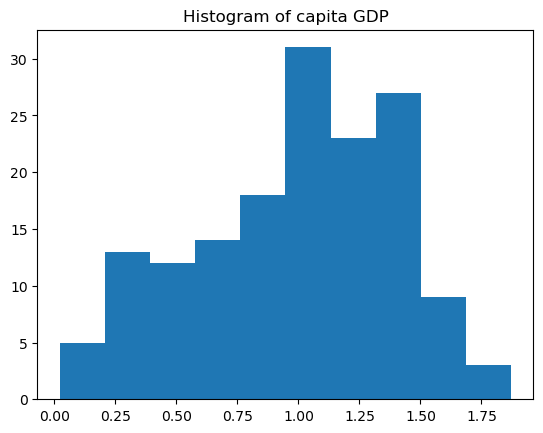

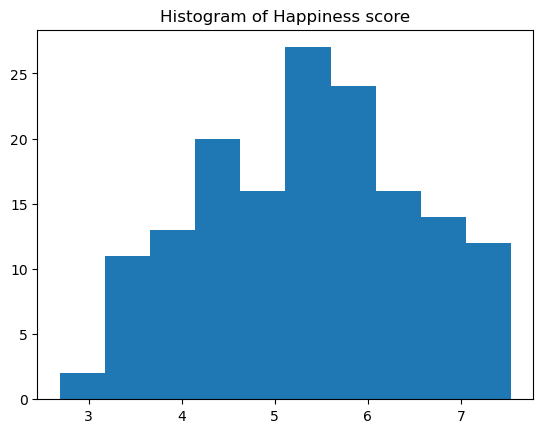

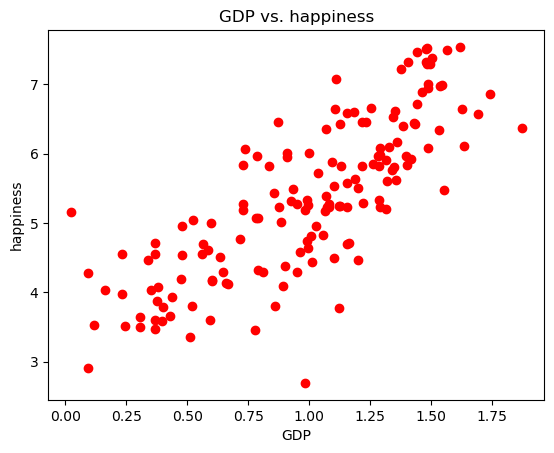

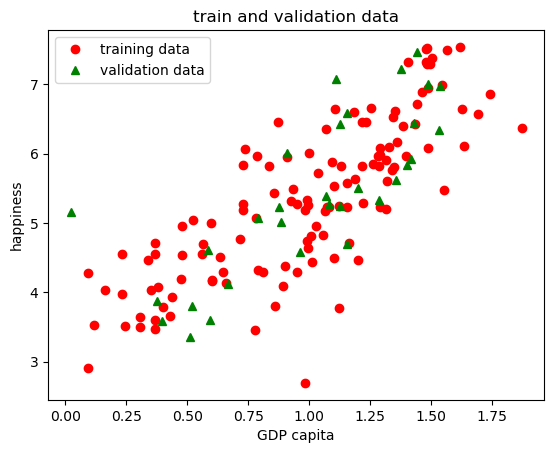

the learnt model: f(x) =  3.2206509678660415  +  2.144976360228615  * x


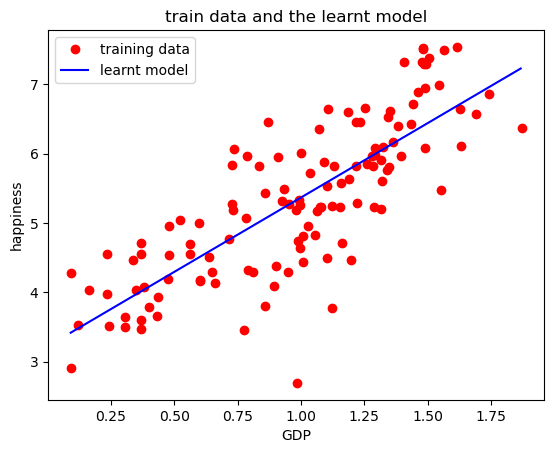

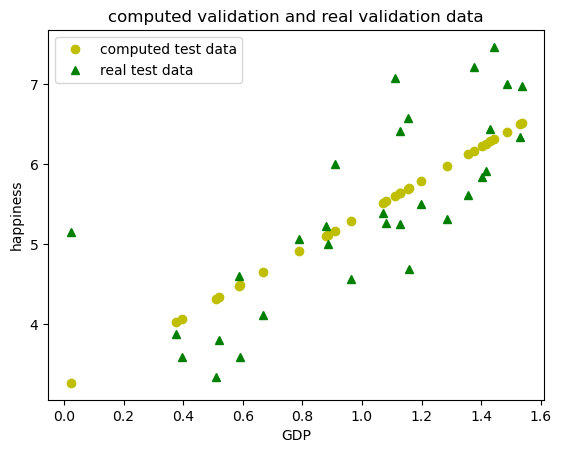

prediction error (manual):  0.5252836514420095


In [19]:
crtDir =  os.getcwd()


inputs, outputs = loadData("v1_world-happiness-report-2017.csv", 'Economy..GDP.per.Capita.', 'Happiness.Score')
print('in:  ', inputs[:5])
print('out: ', outputs[:5])


def plotDataHistogram(x, variableName):
    n, bins, patches = plt.hist(x, 10)
    plt.title('Histogram of ' + variableName)
    plt.show()

plotDataHistogram(inputs, 'GDP')
plotDataHistogram(outputs, 'Happiness score')


plt.plot(inputs, outputs, 'ro') 
plt.xlabel('GDP')
plt.ylabel('happiness')
plt.title('GDP vs. happiness')
plt.show()

random.seed(5)
indexes = [i for i in range(len(inputs))]

trainSample = random.sample(indexes,k= int(0.8 * len(inputs)))
validationSample = [i for i in indexes  if not i in trainSample]

trainInputs = [inputs[i] for i in trainSample]
trainOutputs = [outputs[i] for i in trainSample]

validationInputs = [inputs[i] for i in validationSample]
validationOutputs = [outputs[i] for i in validationSample]

plt.plot(trainInputs, trainOutputs, 'ro', label = 'training data')   #train data 
plt.plot(validationInputs, validationOutputs, 'g^', label = 'validation data')     #test data 
plt.title('train and validation data')
plt.xlabel('GDP')
plt.ylabel('happiness')
plt.legend()
plt.show()

regressor=MyLinearUnivariateRegression()
regressor.fit(trainInputs,trainOutputs)
w0,w1=regressor.intercept_,regressor.coef_
print('the learnt model: f(x) = ', w0, ' + ', w1, ' * x')

noOfPoints = 1000
xref = []
val = min(trainInputs)
step = (max(trainInputs) - min(trainInputs)) / noOfPoints
for i in range(1, noOfPoints):
    xref.append(val)
    val += step
yref = [w0 + w1 * el for el in xref]

plt.plot(trainInputs, trainOutputs, 'ro', label='training data')
plt.plot(xref, yref, 'b-', label='learnt model')
plt.title('train data and the learnt model')
plt.xlabel('GDP')
plt.ylabel('happiness')
plt.legend()
plt.show()

computed_validation_outputs = regressor.predict([[x] for x in validationInputs])

plt.plot(validationInputs, computed_validation_outputs, 'yo', label='computed test data')
plt.plot(validationInputs, validationOutputs, 'g^', label='real test data')
plt.title('computed validation and real validation data')
plt.xlabel('GDP')
plt.ylabel('happiness')
plt.legend()
plt.show()

error = 0.0
for t1, t2 in zip(computed_validation_outputs, validationOutputs):
    error += (t1 - t2) ** 2
error = error / len(validationOutputs)
print('prediction error (manual): ', error)


In [ ]:
Family vs happiness

in:   [1.510041952, 1.510041952, 1.510041952, 1.510041952, 1.510041952]
out:  [7.537000179, 7.521999836, 7.504000187, 7.493999958, 7.468999863]


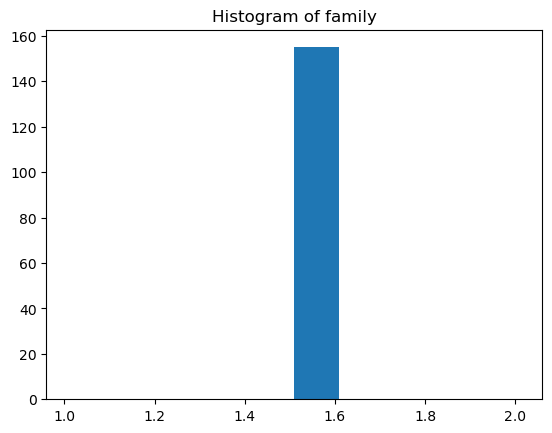

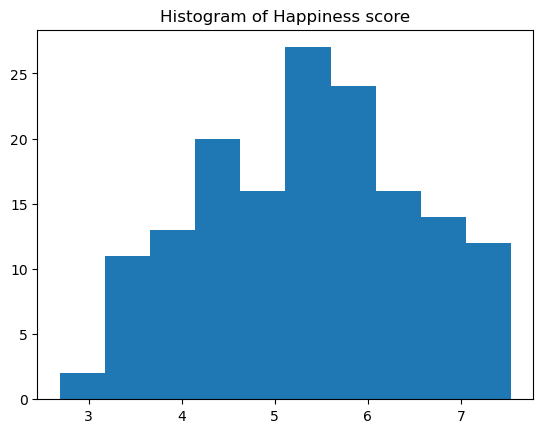

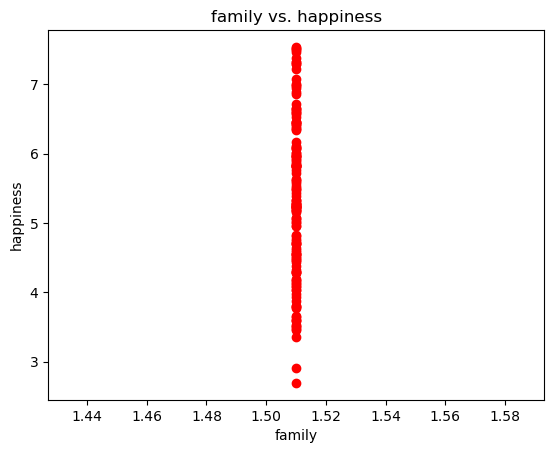

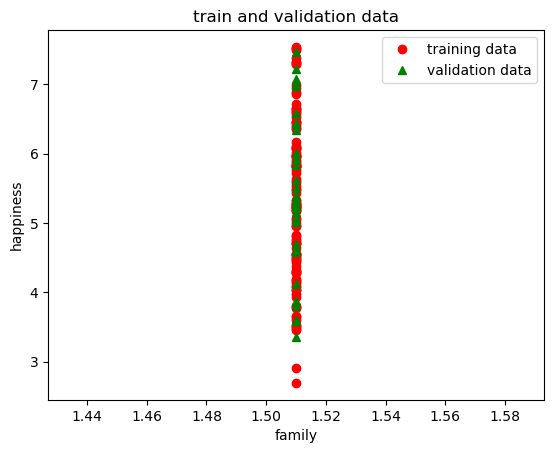

the learnt model: f(x) =  -2.215242004516112  +  5.0  * x


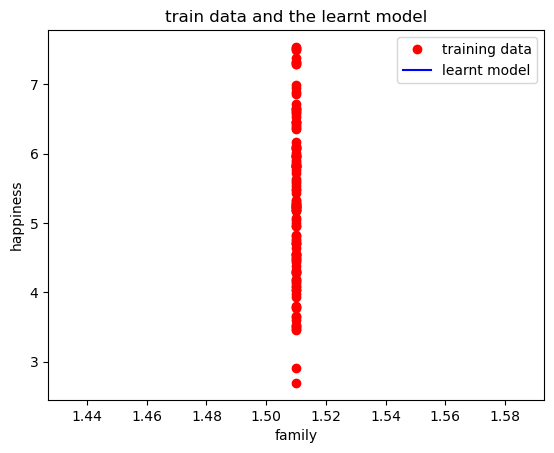

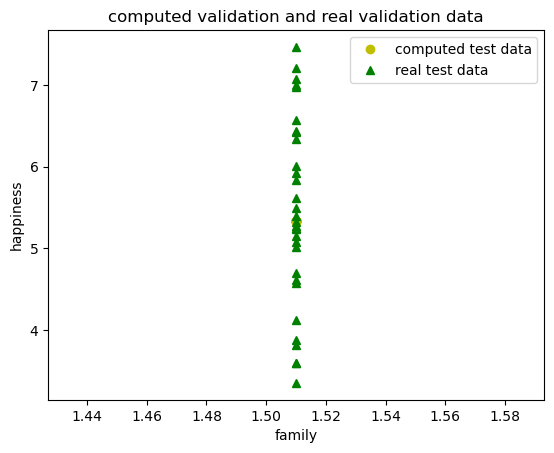

prediction error (manual):  1.3047948832321823


In [20]:
crtDir =  os.getcwd()


inputs, outputs = loadData("v1_world-happiness-report-2017.csv", 'Family', 'Happiness.Score')
print('in:  ', inputs[:5])
print('out: ', outputs[:5])


def plotDataHistogram(x, variableName):
    n, bins, patches = plt.hist(x, 10)
    plt.title('Histogram of ' + variableName)
    plt.show()

plotDataHistogram(inputs, 'family')
plotDataHistogram(outputs, 'Happiness score')


plt.plot(inputs, outputs, 'ro') 
plt.xlabel('family')
plt.ylabel('happiness')
plt.title('family vs. happiness')
plt.show()

random.seed(5)
indexes = [i for i in range(len(inputs))]

trainSample = random.sample(indexes,k= int(0.8 * len(inputs)))
validationSample = [i for i in indexes  if not i in trainSample]

trainInputs = [inputs[i] for i in trainSample]
trainOutputs = [outputs[i] for i in trainSample]

validationInputs = [inputs[i] for i in validationSample]
validationOutputs = [outputs[i] for i in validationSample]

plt.plot(trainInputs, trainOutputs, 'ro', label = 'training data')   #train data 
plt.plot(validationInputs, validationOutputs, 'g^', label = 'validation data')     #test data 
plt.title('train and validation data')
plt.xlabel('family')
plt.ylabel('happiness')
plt.legend()
plt.show()

regressor=MyLinearUnivariateRegression()
regressor.fit(trainInputs,trainOutputs)
w0,w1=regressor.intercept_,regressor.coef_
print('the learnt model: f(x) = ', w0, ' + ', w1, ' * x')

noOfPoints = 1000
xref = []
val = min(trainInputs)
step = (max(trainInputs) - min(trainInputs)) / noOfPoints
for i in range(1, noOfPoints):
    xref.append(val)
    val += step
yref = [w0 + w1 * el for el in xref]

plt.plot(trainInputs, trainOutputs, 'ro', label='training data')
plt.plot(xref, yref, 'b-', label='learnt model')
plt.title('train data and the learnt model')
plt.xlabel('family')
plt.ylabel('happiness')
plt.legend()
plt.show()

computed_validation_outputs = regressor.predict([[x] for x in validationInputs])

plt.plot(validationInputs, computed_validation_outputs, 'yo', label='computed test data')
plt.plot(validationInputs, validationOutputs, 'g^', label='real test data')
plt.title('computed validation and real validation data')
plt.xlabel('family')
plt.ylabel('happiness')
plt.legend()
plt.show()

error = 0.0
for t1, t2 in zip(computed_validation_outputs, validationOutputs):
    error += (t1 - t2) ** 2
error = error / len(validationOutputs)
print('prediction error (manual): ', error)


In [ ]:
GPB si Freedom vs happiness

in1:  [1.616463184, 1.482383013, 1.48063302, 1.564979553, 1.443571925]
in2:  [0.635422587, 0.626006722, 0.627162635, 0.620070577, 0.617950857]
out:  [7.537000179, 7.521999836, 7.504000187, 7.493999958, 7.468999863]


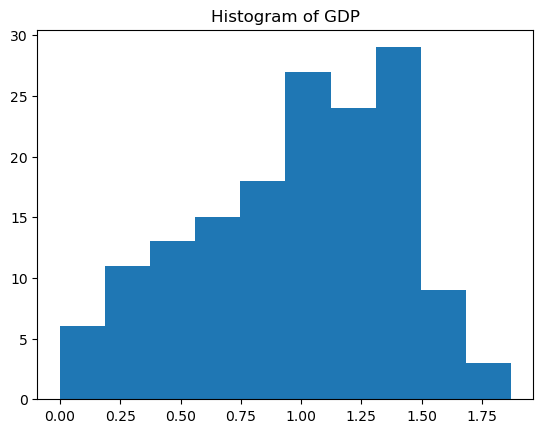

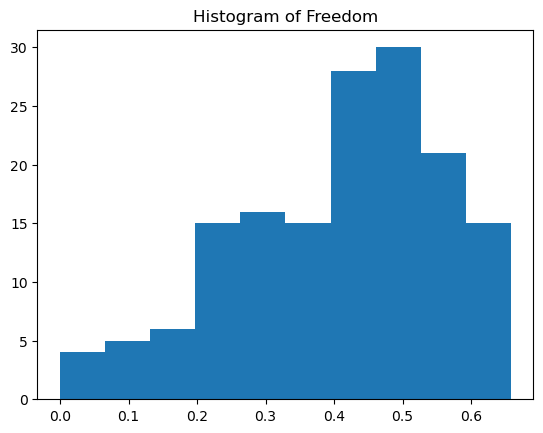

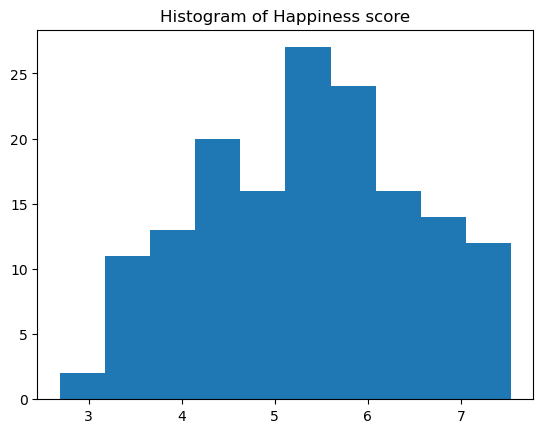

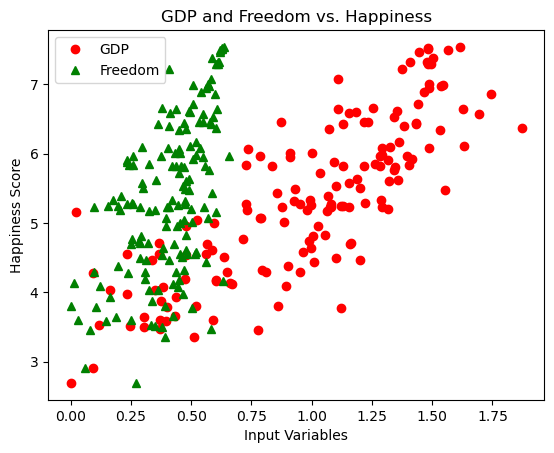

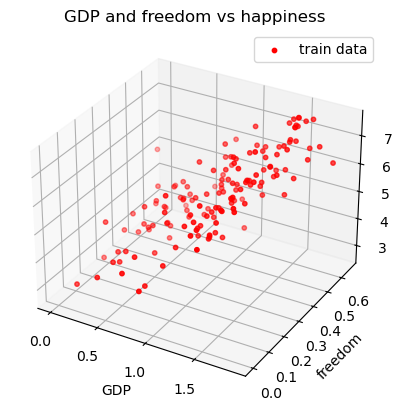

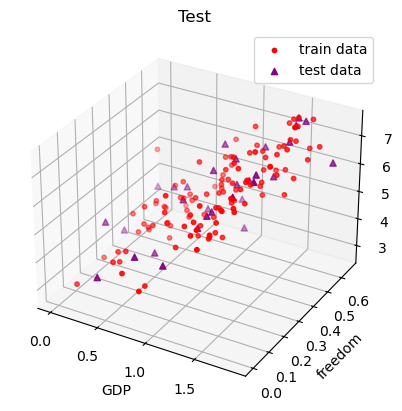

the learnt model: f(x) =  1.485861267799714  +  2.218199371203806  * x1 +  4.100099356371395 * x2


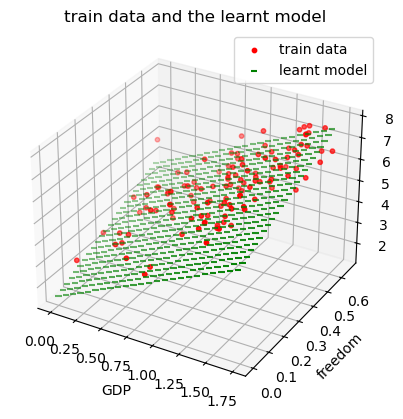

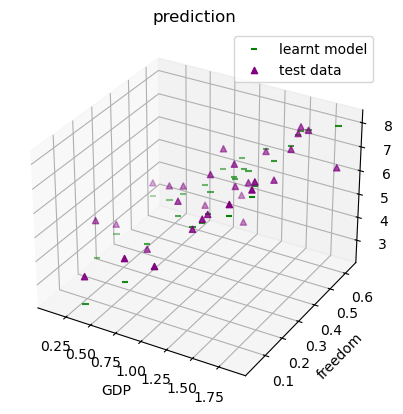

prediction error (manual):  0.6719109934976815


In [36]:
def loadData(fileName, inputVariabName1, inputVariabName2, outputVariabName):
    data = []
    dataNames = []
    with open(fileName) as csv_file:
        csv_reader = csv.reader(csv_file, delimiter=',')
        line_count = 0
        for row in csv_reader:
            if line_count == 0:
                dataNames = row
            else:
                data.append(row)
            line_count += 1
    selectedVariable1 = dataNames.index(inputVariabName1)
    inputs1 = [float(row[selectedVariable1]) if row[selectedVariable1] != '' else None for row in data]
    selectedVariable2 = dataNames.index(inputVariabName2)
    inputs2 = [float(row[selectedVariable2]) if row[selectedVariable2] != '' else None for row in data]

    mean_value1 = sum([val for val in inputs1 if val is not None]) / len([val for val in inputs1 if val is not None])
    mean_value2 = sum([val for val in inputs2 if val is not None]) / len([val for val in inputs2 if val is not None])

    for i in range(len(inputs1)):
        if inputs1[i] is None:
            inputs1[i] = mean_value1
        if inputs2[i] is None:
            inputs2[i] = mean_value2

    selectedOutput = dataNames.index(outputVariabName)
    outputs = [float(row[selectedOutput]) for row in data]
    
    return inputs1, inputs2, outputs


inputs1, inputs2, outputs = loadData("v1_world-happiness-report-2017.csv", 'Economy..GDP.per.Capita.', 'Freedom', 'Happiness.Score')
print('in1: ', inputs1[:5])
print('in2: ', inputs2[:5])
print('out: ', outputs[:5])

# Plot the histograms associated with input data and output data

def plotDataHistogram(x, variableName):
    n, bins, patches = plt.hist(x, 10)
    plt.title('Histogram of ' + variableName)
    plt.show()

plotDataHistogram(inputs1, 'GDP')
plotDataHistogram(inputs2, 'Freedom')
plotDataHistogram(outputs, 'Happiness score')

# Check linearity

plt.plot(inputs1, outputs, 'ro', label='GDP') 
plt.plot(inputs2, outputs, 'g^', label='Freedom') 
plt.xlabel('Input Variables')
plt.ylabel('Happiness Score')
plt.title('GDP and Freedom vs. Happiness')
plt.legend()
plt.show()



def plot3Ddata(x1_train, x2_train, y_train, x1_model=None, x2_model=None, y_model=None, x1_test=None, x2_test=None,
               y_test=None,
               title=None):
    ax = plt.axes(projection='3d')
    if x1_train:
        ax.scatter(x1_train, x2_train, y_train, c='r', marker='o', label='train data', s=10)
    if x1_model:
        ax.scatter(x1_model, x2_model, y_model, c='g', marker='_', label='learnt model')
    if x1_test:
        ax.scatter(x1_test, x2_test, y_test, c='purple', marker='^', label='test data')
    plt.title(title)
    ax.set_xlabel("GDP")
    ax.set_ylabel("freedom")
    ax.set_zlabel("happiness")
    plt.legend()
    plt.show()


plot3Ddata(inputs1, inputs2, outputs, [], [], [], [], [], [], "GDP and freedom vs happiness")


inputs=[list(pair) for pair in zip(inputs1, inputs2)]
indexes = [i for i in range(len(inputs))]

trainSample = random.sample(indexes,k=int(0.8 * len(inputs)))
validationSample = [i for i in range(len(inputs)) if i not in trainSample]

trainInputs = [inputs[i] for i in trainSample]
trainOutputs = [outputs[i] for i in trainSample]

validationInputs = [inputs[i] for i in validationSample]
validationOutputs = [outputs[i] for i in validationSample]

trainInputs1=[td[0] for td in trainInputs]
trainInputs2=[td[1] for td in trainInputs]

validationInputs1=[vd[0] for vd in validationInputs]
validationInputs2=[vd[1] for vd in validationInputs]


validationOutputs = [outputs[i] for i in validationSample]

plot3Ddata(trainInputs1,trainInputs2,trainOutputs,[],[],[],validationInputs1,validationInputs2,validationOutputs,"Test")

regressor=MyRegression2Freatures()
regressor.fit(trainInputs,trainOutputs)
w0, w1, w2 = regressor.intercept_, regressor.coef_[0], regressor.coef_[1]

print('the learnt model: f(x) = ', w0, ' + ', w1, ' * x1 + ', w2, '* x2')

noOfPoints = 25
xref = []
val = min(inputs1)
step = (max(inputs1) - val) / noOfPoints
for i in range(1, noOfPoints):
    for j in range(1, noOfPoints):
        xref.append(val)
    val += step

xref2 = []
val = min(inputs2)
step = (max(inputs2) - val) / noOfPoints
for i in range(1, noOfPoints):
    aux = val
    for j in range(1, noOfPoints):
        xref2.append(aux)
        aux += step

yref = [w0 + w1 * el1 + w2 * el2 for el1, el2 in zip(xref, xref2)]
plot3Ddata(trainInputs1,trainInputs2,trainOutputs, xref, xref2, yref, [], [], [], 'train data and the learnt model')

computed_test_outputs = regressor.predict(validationInputs)

plot3Ddata([], [], [], validationInputs1, validationInputs2, computed_test_outputs, validationInputs1, validationInputs2, validationOutputs, "prediction")

error = 0.0
for t1, t2 in zip(computed_test_outputs, validationOutputs):
    error += (t1 - t2) ** 2
error = error / len(validationOutputs)
print('prediction error (manual): ', error)
